Ce que fait ce code :

On génère une série temporelle simple : 𝑦 =sin(𝑥 )
y=sin(x).

On crée des séquences glissantes de longueur seq_length.

    Entrée : 10 valeurs successives.
    Sortie : la valeur suivante.

Le RNN apprend à prédire la prochaine valeur de la série.

Après l’entraînement, on compare :



les valeurs réelles,
les valeurs prédites par le modèle.


C’est un exemple minimal parfait pour montrer comment ton SimpleRNN peut faire de la prédiction de séries temporelles

In [41]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

### Modele ###

In [42]:
# Ton modèle
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, h_n = self.rnn(x)
        out = self.fc(out[:, -1, :])  # dernier pas de temps
        return out

### Création de données (série temporelle simple) ###
### Exemple : y = sin(x) ###

In [43]:
# 1. Création de données (série temporelle simple)
# Exemple : y = sin(x)
time_steps = 200
x = np.linspace(0, 20, time_steps)
data = np.sin(x)

# 2. Création des séquences (fenêtre glissante)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i+seq_length])
        ys.append(data[i+seq_length])
    return np.array(xs), np.array(ys)

seq_length = 10
X, y = create_sequences(data, seq_length)

# Mise en forme pour PyTorch
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (batch, seq_len, 1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (batch, 1)

# 3. Initialisation du modèle, loss et optimiseur
model = SimpleRNN(input_size=1, hidden_size=50, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


### Entrainement ###

In [44]:
epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/300], Loss: 0.0001
Epoch [100/300], Loss: 0.0000
Epoch [150/300], Loss: 0.0000
Epoch [200/300], Loss: 0.0000
Epoch [250/300], Loss: 0.0000
Epoch [300/300], Loss: 0.0000


### Prédiction ###

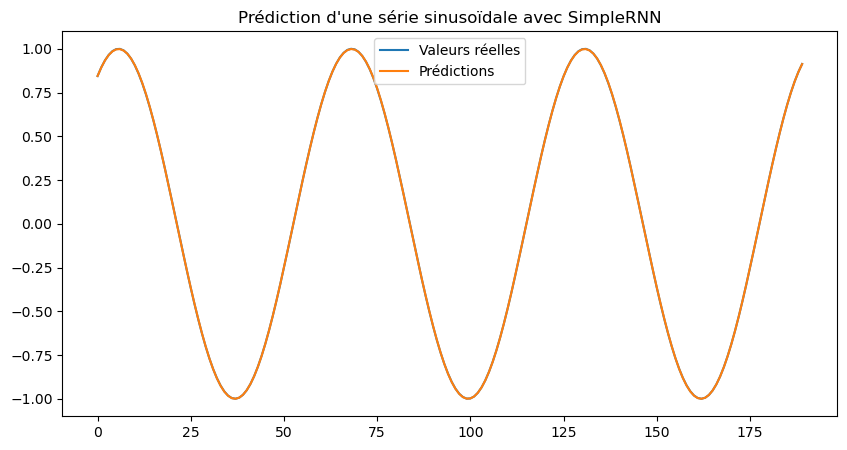

In [45]:
model.eval()
with torch.no_grad():
    predictions = model(X)

# Conversion en numpy pour affichage
predictions = predictions.squeeze().numpy()
y_true = y.squeeze().numpy()

# 6. Visualisation
plt.figure(figsize=(10,5))
plt.plot(y_true, label="Valeurs réelles")
plt.plot(predictions, label="Prédictions")
plt.legend()
plt.title("Prédiction d'une série sinusoïdale avec SimpleRNN")
plt.show()